# Trace Count v4: v2-Style Steering

This notebook follows `pipeline_v4_steering_codex_prompt.md`. It intentionally reuses the v2 symbolic counting setup and v2-style HuggingFace GPT-2 architecture with learned absolute positional embeddings. The new part is mechanistic: hidden-state cache, probes, direction extraction, steering, and patching.

In [4]:
from pathlib import Path
import os
import pathlib
import subprocess
import sys

# Minimal Colab/VSCode setup. Keep dependency installs off unless an import check fails.
REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
REPO_DIR = Path("/content/Synthetic_CoT_NiaH_Count")
PULL_REPO = True
REPAIR_NUMPY_ABI = True
INSTALL_MINIMAL_DEPS = False
INSTALL_EDITABLE_PACKAGE = False

if Path("/content").exists():
    if REPO_DIR.exists():
        os.chdir(REPO_DIR)
        if PULL_REPO and (REPO_DIR / ".git").exists():
            subprocess.run(["git", "pull"], check=False)
    else:
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
        os.chdir(REPO_DIR)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from scripts.colab_setup import setup_colab

ROOT = setup_colab(
    repo_url=REPO_URL,
    repo_dir=REPO_DIR,
    pull=False,
    repair_numpy_abi=REPAIR_NUMPY_ABI,
    install_deps=INSTALL_MINIMAL_DEPS,
    install_editable=INSTALL_EDITABLE_PACKAGE,
)

numpy=2.0.2 pandas=2.2.2 scipy=1.16.3
cwd = /content/Synthetic_CoT_NiaH_Count
Dependency import check passed.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Runtime settings

- `debug`: quick end-to-end sanity check.
- `main`: v2-style main setting: two models, one seed by default, `1..10` counts, GPT-2 learned absolute positions.
- `stage='all'` runs training, behavior eval, hidden cache, probes, direction extraction, patching, steering, plots, and a markdown/html artifact report.

In [6]:
PRESET = 'main'  # 'debug' or 'main'
STAGE = 'all'
SEEDS = '1234'
OUT_ROOT = 'runs/synthetic_niah_v4'
RUN_NAME = ''  # empty means auto: {preset}_seed{seeds}
if not RUN_NAME:
    RUN_NAME = f"{PRESET}_seed{SEEDS.replace(',', '_')}"
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
SKIP_COMPLETED = True

print({
    'PRESET': PRESET,
    'STAGE': STAGE,
    'SEEDS': SEEDS,
    'OUT_ROOT': OUT_ROOT,
    'RUN_NAME': RUN_NAME,
    'DEVICE': DEVICE,
    'SKIP_COMPLETED': SKIP_COMPLETED,
})


{'PRESET': 'main', 'STAGE': 'all', 'SEEDS': '1234', 'OUT_ROOT': 'runs/synthetic_niah_v4', 'RUN_NAME': 'main_seed1234', 'DEVICE': 'cuda', 'SKIP_COMPLETED': True}


In [7]:
cmd = [
    sys.executable, '-u', '-m', 'synthetic_niah_v4.run_v4',
    '--preset', PRESET,
    '--stage', STAGE,
    '--device', DEVICE,
    '--out-root', OUT_ROOT,
    '--seeds', SEEDS,
]
if RUN_NAME:
    cmd += ['--run-name', RUN_NAME]
if SKIP_COMPLETED:
    cmd.append('--skip-completed')
print(' '.join(cmd), flush=True)
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
captured = []
for line in proc.stdout:
    print(line, end='')
    captured.append(line.rstrip())
returncode = proc.wait()
if returncode:
    print('---- Last 120 log lines ----')
    print('\n'.join(captured[-120:]))
    raise subprocess.CalledProcessError(returncode, cmd)

RUN_DIR = None
for line in reversed(captured):
    if line.startswith('FINAL_RUN_DIR '):
        RUN_DIR = Path(line.split(' ', 1)[1].strip())
        break
if RUN_DIR is None:
    RUN_DIR = Path(OUT_ROOT) / RUN_NAME if RUN_NAME else Path(OUT_ROOT)
print('RUN_DIR =', RUN_DIR)

/usr/bin/python3 -u -m synthetic_niah_v4.run_v4 --preset main --stage all --device cuda --out-root runs/synthetic_niah_v4 --seeds 1234 --run-name main_seed1234 --skip-completed
[v4] stage=train
[v4 train] non_thinking seed=1234

v4 non_thinking seed=1234: 100%|██████████| 10000/10000 [12:14<00:00, 13.61it/s, loss=0.0000, lr=8.94e-12]
[v4 train] thinking seed=1234

v4 thinking seed=1234: 100%|██████████| 10000/10000 [13:54<00:00, 11.99it/s, loss=0.0000, lr=8.94e-12]
[v4] stage=behavior_eval
[v4] stage=cache
[v4] stage=probe
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it wi

## Result tables

The most important tables are behavior accuracy, probe results, direction diagnostics, and steering/patching. Probe accuracy alone means decodability; steering or patching is the causal check.

In [8]:
import pandas as pd
from IPython.display import Markdown, display

tables = RUN_DIR / 'tables'
for name in [
    'behavior_accuracy_by_count.csv',
    'probe_results.csv',
    'direction_metrics.csv',
    'steering_results.csv',
    'interchange_patching_results.csv',
]:
    path = tables / name
    display(Markdown(f'### `{name}`'))
    if path.exists() and path.stat().st_size > 0:
        display(pd.read_csv(path).head(20))
    else:
        display(Markdown('_No rows._'))

### `behavior_accuracy_by_count.csv`

,model_type,eval_mode,count,final_accuracy
0,non_thinking,direct,1,1.0
1,non_thinking,direct,2,1.0
2,non_thinking,direct,3,1.0
3,non_thinking,direct,4,1.0
4,non_thinking,direct,5,1.0
5,non_thinking,direct,6,1.0
6,non_thinking,direct,7,1.0
7,non_thinking,direct,8,1.0
8,non_thinking,direct,9,1.0
9,non_thinking,direct,10,1.0


### `probe_results.csv`

,model_type,eval_mode,anchor_name,anchor_k,target,hook_name,layer,probe_type,raw_or_residualized,train_n,test_n,accuracy,r2,mae,ce_loss,position_baseline_acc,token_baseline_acc,trace_len_baseline_acc,leakage_prone
0,non_thinking,direct,ans_token,NaN,final_count,embed,-1,ridge_scalar,raw,1250,1250,0.1024,-0.000015,2.513654,NaN,0.1016,0.1016,0.1016,False
1,non_thinking,direct,ans_token,NaN,final_count,embed,-1,multiclass_logistic,raw,1250,1250,0.1016,NaN,NaN,2.302585,0.1016,0.1016,0.1016,False
2,non_thinking,direct,ans_token,NaN,final_count,embed,-1,ridge_scalar,residualized,1250,1250,0.1024,-0.000015,2.513654,NaN,0.1016,0.1016,0.1016,False
3,non_thinking,direct,ans_token,NaN,final_count,embed,-1,multiclass_logistic,residualized,1250,1250,0.1016,NaN,NaN,2.302585,0.1016,0.1016,0.1016,False
4,non_thinking,direct,ans_token,NaN,final_count,final_norm,4,ridge_scalar,raw,1250,1250,1.0000,0.999931,0.018101,NaN,0.1016,0.1016,0.1016,False
5,non_thinking,direct,ans_token,NaN,final_count,final_norm,4,multiclass_logistic,raw,1250,1250,1.0000,NaN,NaN,0.000444,0.1016,0.1016,0.1016,False
6,non_thinking,direct,ans_token,NaN,final_count,final_norm,4,ridge_scalar,residualized,1250,1250,1.0000,0.999931,0.018101,NaN,0.1016,0.1016,0.1016,False
7,non_thinking,direct,ans_token,NaN,final_count,final_norm,4,multiclass_logistic,residualized,1250,1250,1.0000,NaN,NaN,0.000444,0.1016,0.1016,0.1016,False
8,non_thinking,direct,ans_token,NaN,final_count,resid_post_layer_0,0,ridge_scalar,raw,1250,1250,1.0000,0.999868,0.026308,NaN,0.1016,0.1016,0.1016,False
9,non_thinking,direct,ans_token,NaN,final_count,resid_post_layer_0,0,multiclass_logistic,raw,1250,1250,1.0000,NaN,NaN,0.023015,0.1016,0.1016,0.1016,False


### `direction_metrics.csv`

,model_type,eval_mode,anchor_name,anchor_k,hook_name,layer,direction_type,target,norm,projection_slope,projection_r2,cosine_with_ridge,cosine_with_dom,cosine_with_matched_delta,cosine_with_unembedding
0,non_thinking,direct,ans_token,NaN,embed,-1,dom,final_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,non_thinking,direct,ans_token,NaN,embed,-1,matched_delta,final_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,non_thinking,direct,ans_token,NaN,embed,-1,unembedding_adjacent,final_count,1.0,5.961775e-17,NaN,NaN,NaN,NaN,1.000000
3,non_thinking,direct,ans_token,NaN,embed,-1,ridge,final_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,non_thinking,direct,ans_token,NaN,embed,-1,logistic_adjacent,final_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,non_thinking,direct,ans_token,NaN,embed,-1,shuffled_label_probe,final_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,non_thinking,direct,ans_token,NaN,final_norm,4,dom,final_count,1.0,1.297934e+00,0.409771,0.060418,1.000000,1.000000,0.918772
7,non_thinking,direct,ans_token,NaN,final_norm,4,matched_delta,final_count,1.0,1.297934e+00,0.409771,0.060418,1.000000,1.000000,0.918772
8,non_thinking,direct,ans_token,NaN,final_norm,4,unembedding_adjacent,final_count,1.0,1.126043e+00,0.384665,0.056904,0.918772,0.918772,1.000000
9,non_thinking,direct,ans_token,NaN,final_norm,4,ridge,final_count,1.0,1.608571e-01,0.999940,1.000000,0.060418,0.060418,0.056904


### `steering_results.csv`

,model_type,eval_mode,anchor_name,anchor_k,hook_name,layer,direction_type,alpha,n_examples,base_accuracy,...,mean_pred_steered,mean_count_shift,mean_gold_logit_change,mean_correct_logprob_change,mean_target_plus_one_logprob_change,monotonicity_score,validity_rate,count_token_rate,kl_count_distribution_vs_base,control_type
0,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,-6.0,3000,1.0,...,5.5,0.0,-7.522435e-02,-7.549921e-10,6.797562e-02,1.0,1.0,1.0,0.0,none
1,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,-4.0,3000,1.0,...,5.5,0.0,-3.044929e-02,0.000000e+00,2.661486e-02,1.0,1.0,1.0,0.0,none
2,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,-2.0,3000,1.0,...,5.5,0.0,-6.191379e-03,0.000000e+00,4.801734e-03,1.0,1.0,1.0,0.0,none
3,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,-1.0,3000,1.0,...,5.5,0.0,-9.377893e-04,0.000000e+00,3.760827e-04,1.0,1.0,1.0,0.0,none
4,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,0.0,3000,1.0,...,5.5,0.0,-2.543132e-09,0.000000e+00,-7.629395e-09,1.0,1.0,1.0,0.0,none
5,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,1.0,3000,1.0,...,5.5,0.0,-3.283050e-03,0.000000e+00,3.586606e-03,1.0,1.0,1.0,0.0,none
6,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,2.0,3000,1.0,...,5.5,0.0,-1.077899e-02,0.000000e+00,1.114456e-02,1.0,1.0,1.0,0.0,none
7,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,4.0,3000,1.0,...,5.5,0.0,-3.883311e-02,0.000000e+00,3.870395e-02,1.0,1.0,1.0,0.0,none
8,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,ridge,6.0,3000,1.0,...,5.5,0.0,-8.599909e-02,0.000000e+00,8.479328e-02,1.0,1.0,1.0,0.0,none
9,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,random_unit,-6.0,3000,1.0,...,5.5,0.0,-4.847444e-02,-2.662341e-09,1.001792e-01,1.0,1.0,1.0,0.0,random_unit_direction


### `interchange_patching_results.csv`

,model_type,eval_mode,anchor_name,anchor_k,hook_name,layer,donor_count,receiver_count,base_pred,donor_pred,patched_pred,patched_moves_toward_donor,logit_recovery_toward_donor_count,causal_effect_size,n_examples
0,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,2,1,1,2,2,True,-18.854991,1.0,1
1,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,3,1,1,3,3,True,-19.566319,2.0,1
2,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,4,1,1,4,4,True,-20.752011,3.0,1
3,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,5,1,1,5,5,True,-19.599575,4.0,1
4,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,6,1,1,6,6,True,-18.715554,5.0,1
5,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,7,1,1,7,7,True,-21.149436,6.0,1
6,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,8,1,1,8,8,True,-20.677523,7.0,1
7,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,9,1,1,9,9,True,-21.486222,8.0,1
8,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,10,1,1,10,10,True,-18.633990,9.0,1
9,thinking,oracle_trace,ans_token,NaN,resid_post_layer_0,0,1,2,2,1,1,True,-19.205466,-1.0,1


## Figures

These figures summarize: probe accuracy/R2 by anchor and layer, direction agreement with the count-token unembedding, steering dose response, steering controls, and patching from donor to receiver counts.

### `direction_cosine_heatmap.png`

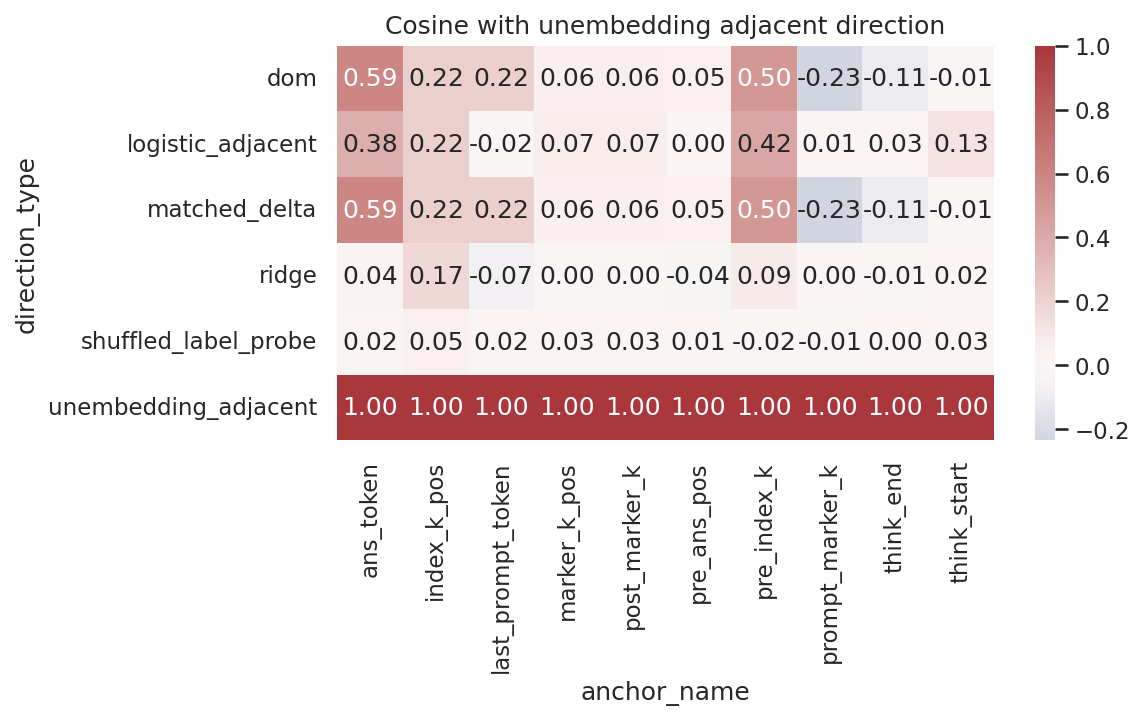

### `input_geometry_projection_trajectories.png`

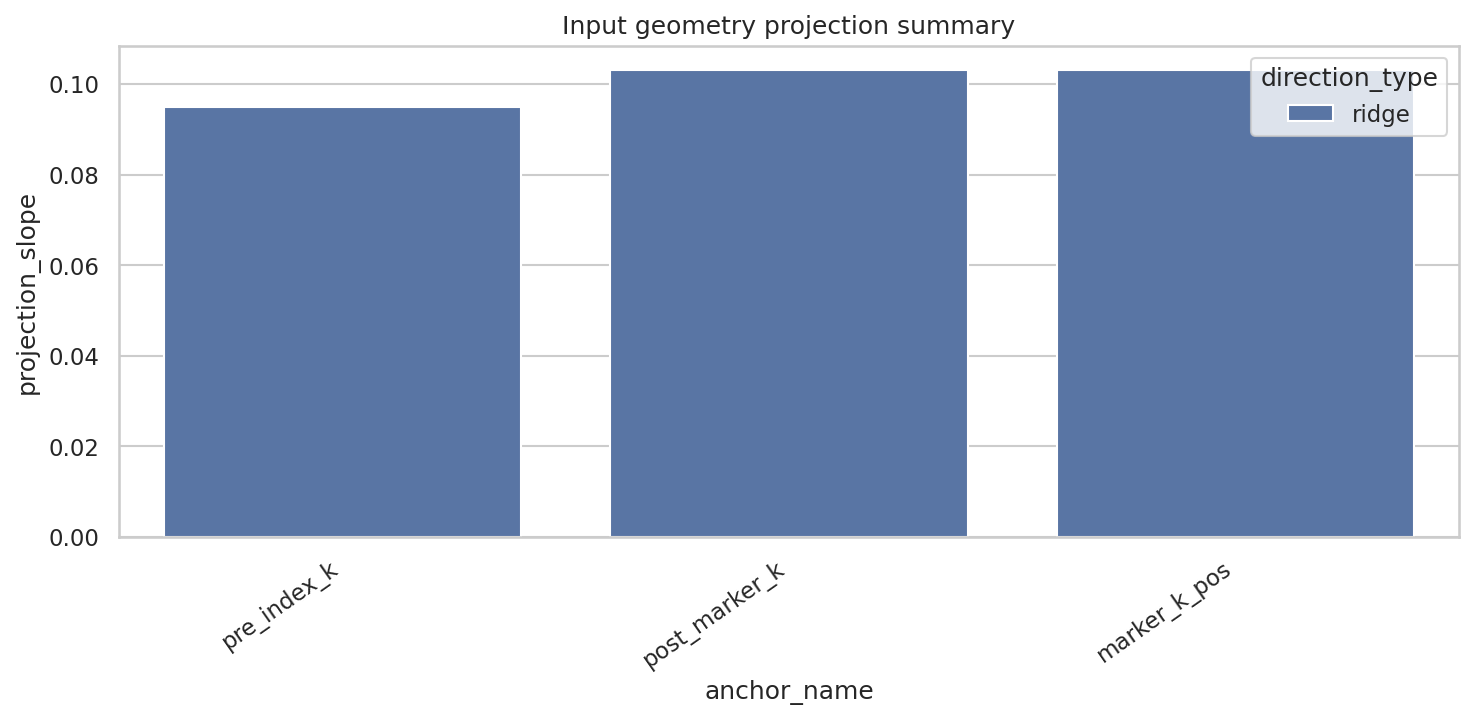

### `interchange_patch_matrix.png`

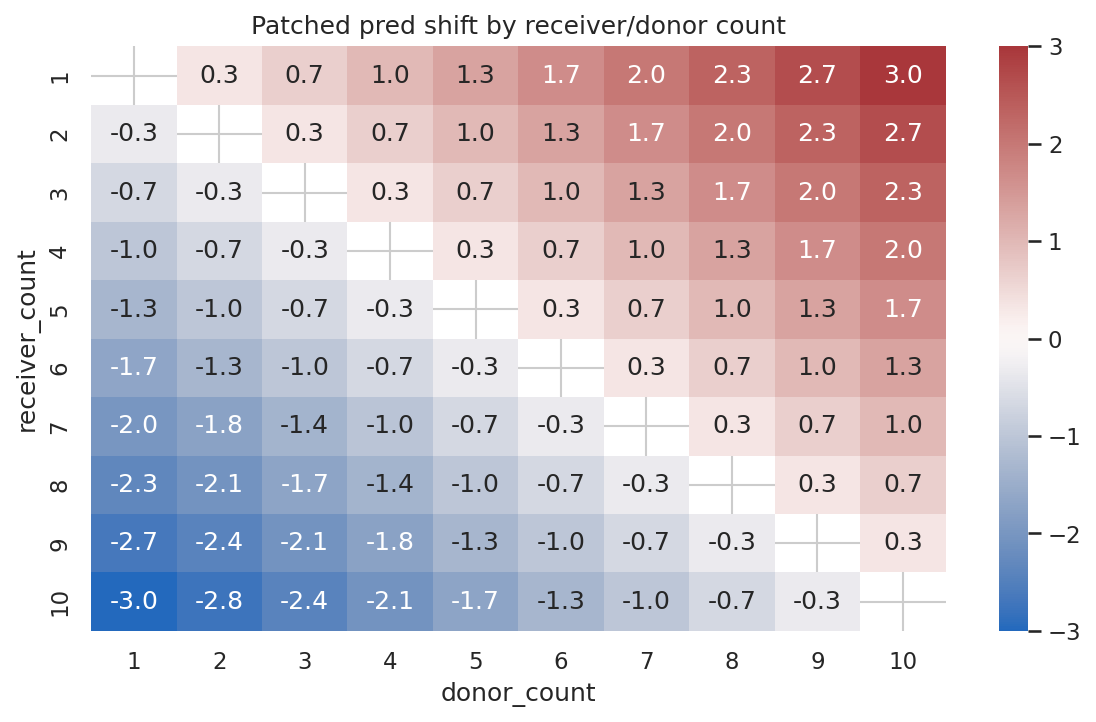

### `probe_acc_by_layer_anchor.png`

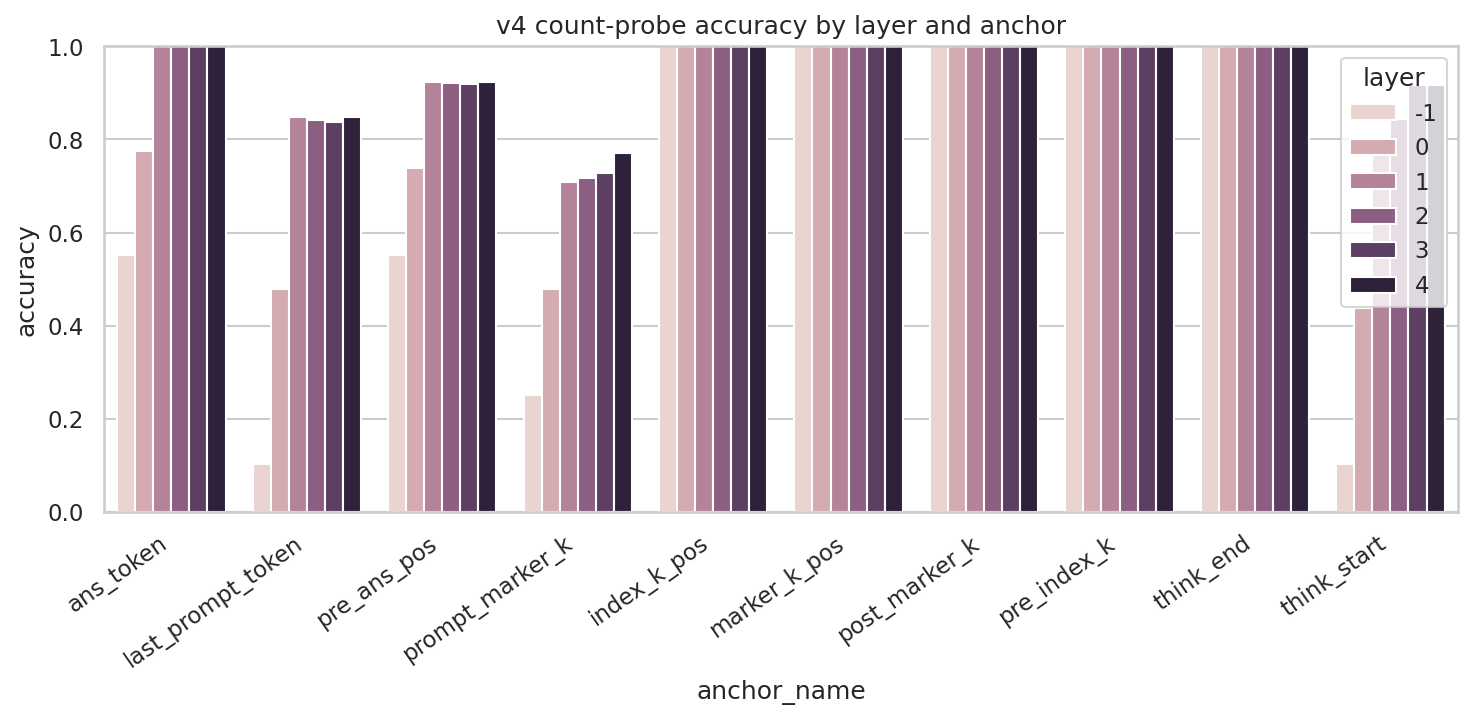

### `probe_minus_baseline_heatmap.png`

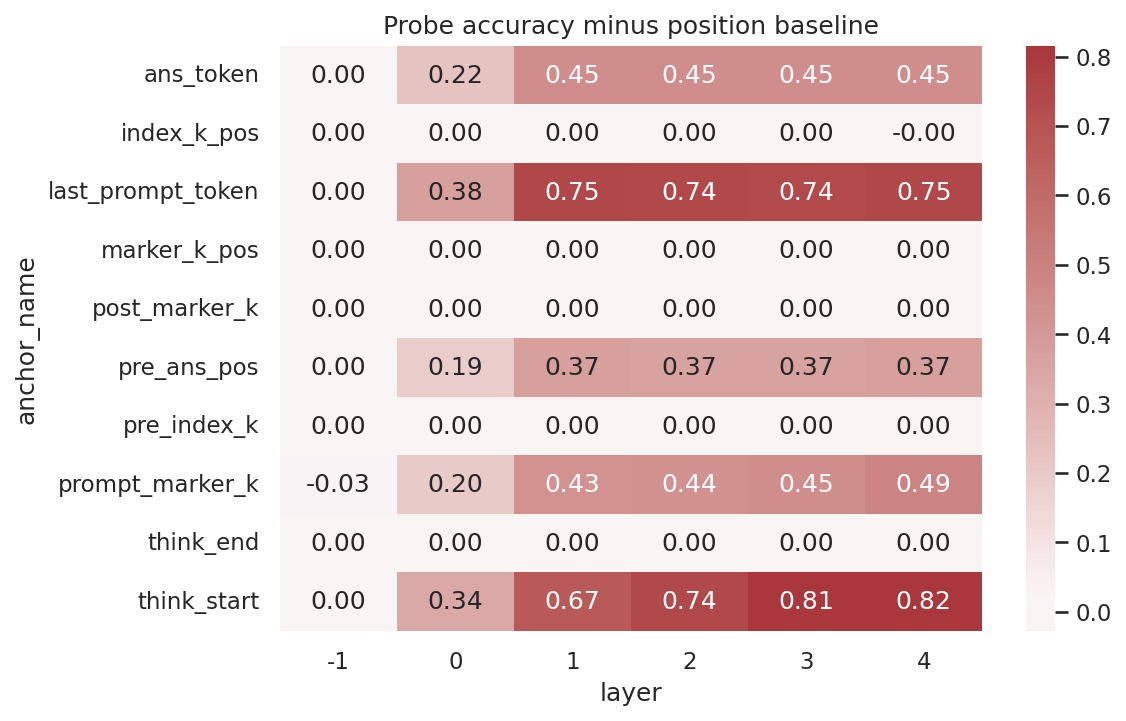

### `probe_r2_by_layer_anchor.png`

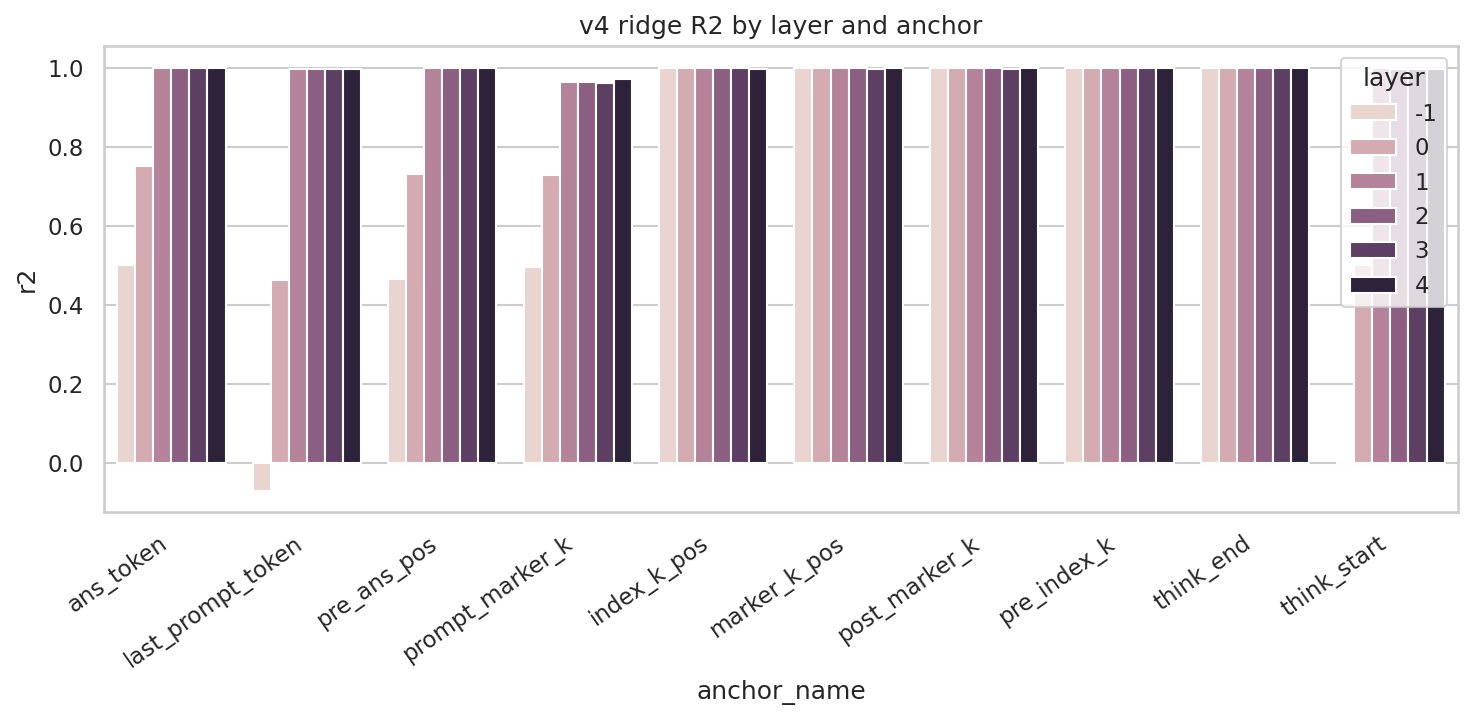

### `projection_by_count.png`

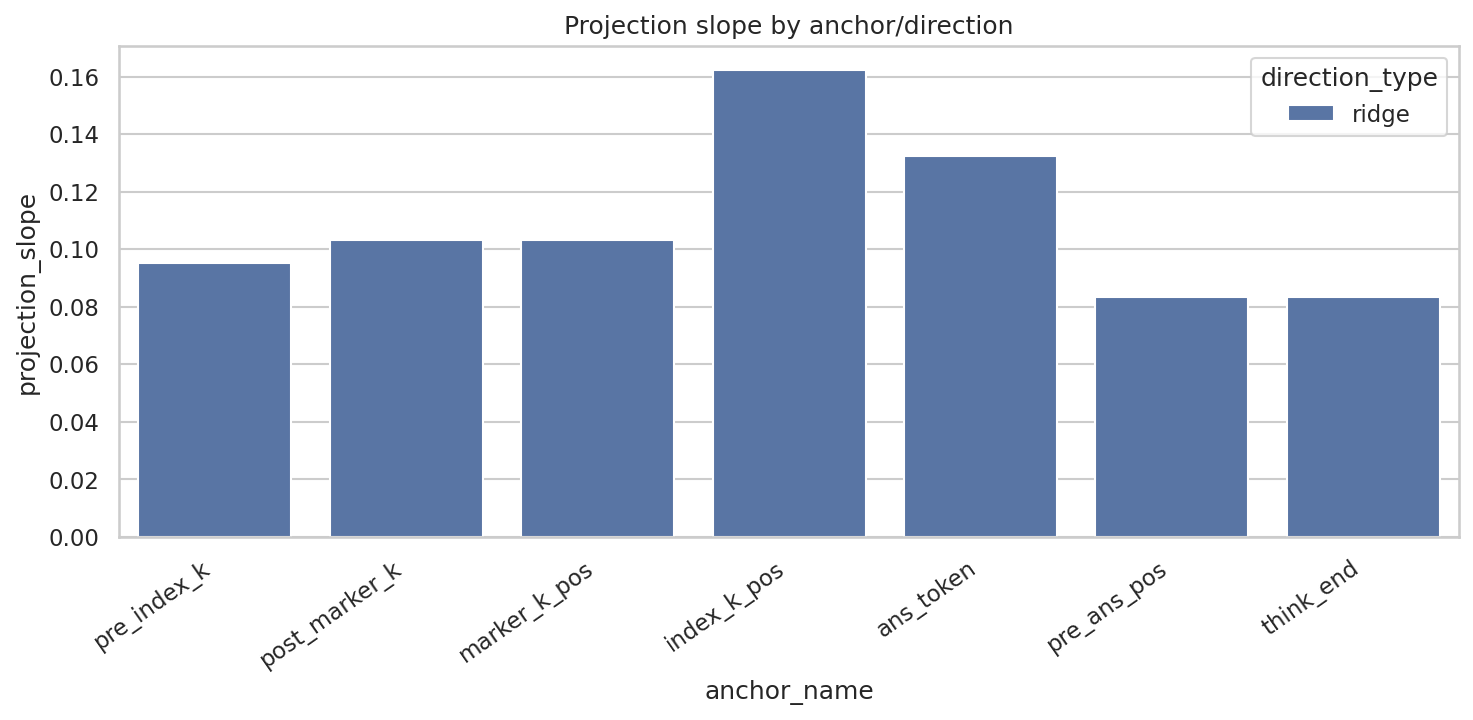

### `steering_controls.png`

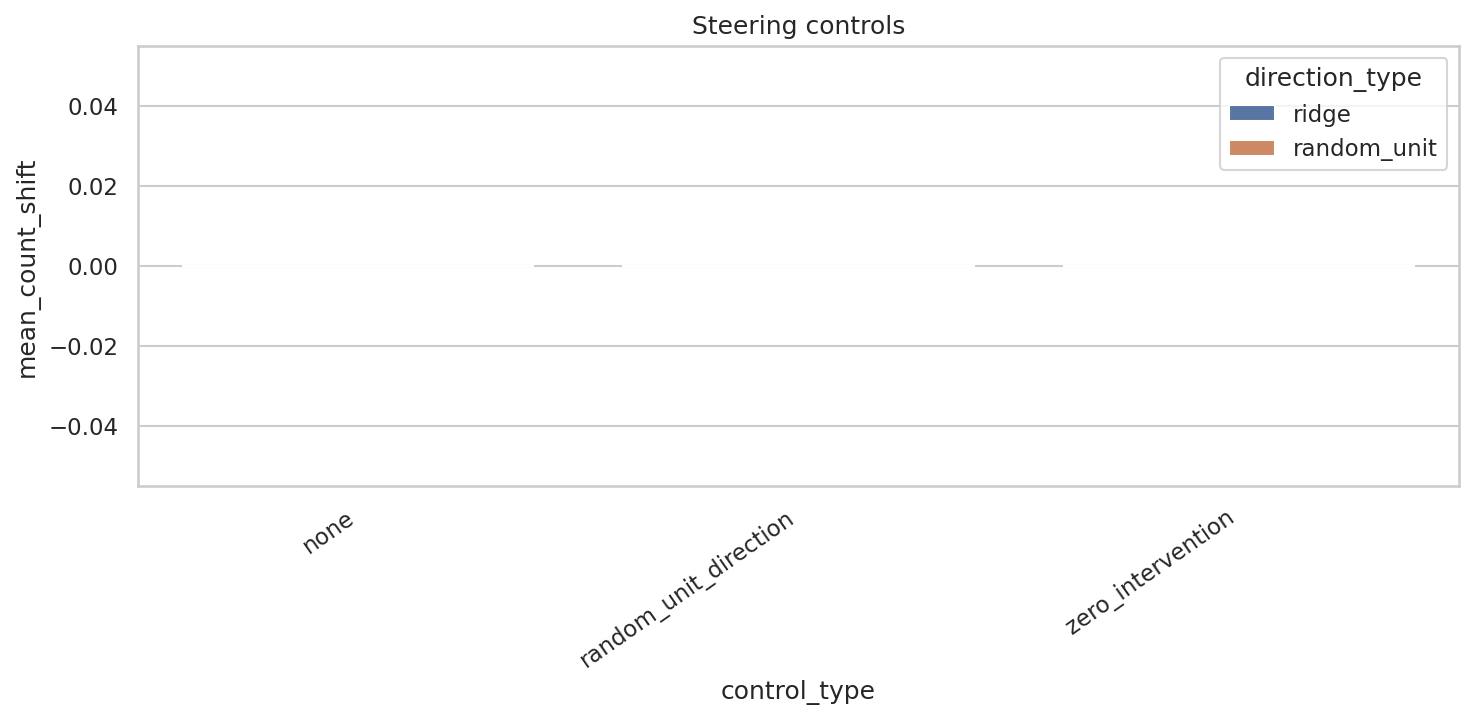

### `steering_dose_response_top_configs.png`

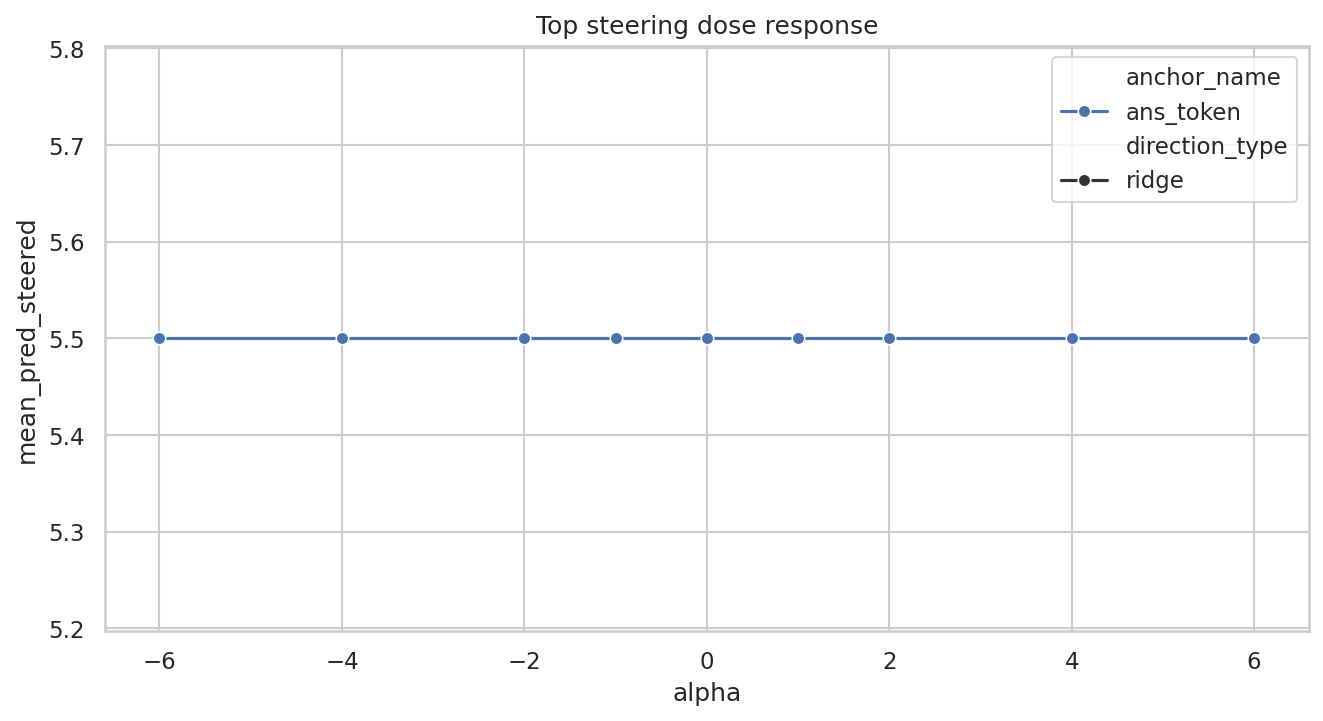

### `steering_heatmap_anchor_layer.png`

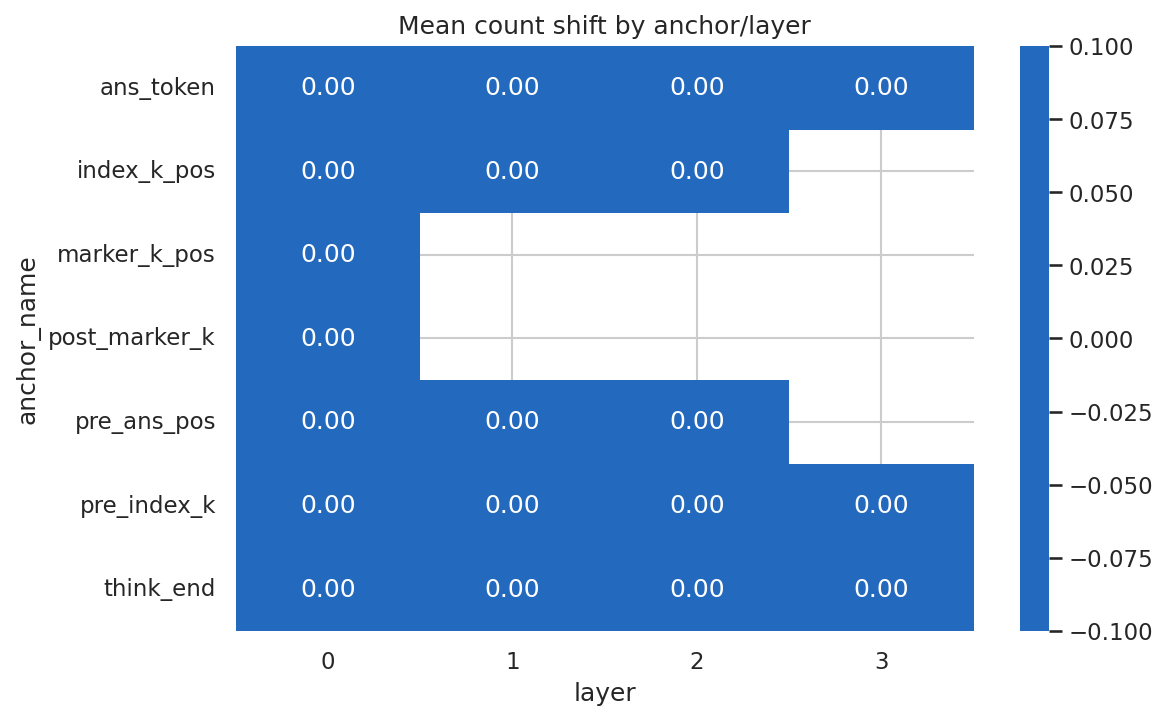

In [9]:
from IPython.display import Image

for fig in sorted((RUN_DIR / 'figures').glob('*.png')):
    display(Markdown(f'### `{fig.name}`'))
    display(Image(filename=str(fig), width=900))

## Save to Google Drive

In [13]:
SAVE_TO_DRIVE = False
DRIVE_SAVE_COMPLETED = False
DRIVE_DIR = '/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/'

if SAVE_TO_DRIVE and Path('/content').exists():
    from google.colab import drive
    import shutil
    drive.mount('/content/drive')
    dest = Path(DRIVE_DIR) / RUN_DIR.name
    if dest.exists():
        shutil.rmtree(dest)
    shutil.copytree(RUN_DIR, dest)
    DRIVE_SAVE_COMPLETED = True
    print('saved to', dest)
else:
    print('SAVE_TO_DRIVE is False; local RUN_DIR:', RUN_DIR)

SAVE_TO_DRIVE is False; local RUN_DIR: runs/synthetic_niah_v4/main_seed1234


## Auto-disconnect Colab Runtime

This cell runs immediately after the Google Drive save cell. It only disconnects when a Drive save was confirmed; local VSCode/Jupyter runs are not force-closed by default.

In [14]:
AUTO_DISCONNECT_AFTER_DRIVE_SAVE = True
FORCE_LOCAL_KERNEL_SHUTDOWN = False

if AUTO_DISCONNECT_AFTER_DRIVE_SAVE and globals().get("DRIVE_SAVE_COMPLETED", False):
    import time

    print("Google Drive save completed. Flushing Drive and disconnecting Colab runtime in 3 seconds...")
    time.sleep(3)
    try:
        from google.colab import drive, runtime

        try:
            drive.flush_and_unmount()
            print("Google Drive flushed and unmounted.")
        except Exception as e:
            print(f"Drive flush/unmount skipped or failed: {e}")
        runtime.unassign()
    except Exception as e:
        print(f"Colab runtime disconnect unavailable or failed: {e}")
        if FORCE_LOCAL_KERNEL_SHUTDOWN:
            import IPython

            IPython.Application.instance().kernel.do_shutdown(restart=False)
        else:
            print("Not forcing local kernel shutdown.")
else:
    print("Auto-disconnect skipped: no confirmed Google Drive save, or AUTO_DISCONNECT_AFTER_DRIVE_SAVE is False.")

Auto-disconnect skipped: no confirmed Google Drive save, or AUTO_DISCONNECT_AFTER_DRIVE_SAVE is False.


## Optional GitHub result upload

In [12]:
PUSH_RESULTS_TO_GITHUB = False
GIT_BRANCH = 'v4-results'

if PUSH_RESULTS_TO_GITHUB:
    subprocess.run(['git', 'checkout', '-B', GIT_BRANCH], check=True)
    subprocess.run(['git', 'add', str(RUN_DIR)], check=True)
    subprocess.run(['git', 'commit', '-m', f'Add v4 results {RUN_DIR.name}'], check=False)
    subprocess.run(['git', 'push', '-u', 'origin', GIT_BRANCH], check=True)
else:
    print('PUSH_RESULTS_TO_GITHUB is False')

PUSH_RESULTS_TO_GITHUB is False
